In [27]:
import sys
sys.path.append("/home/wuhlmann/BA/repo/lamah-ce_lstm/analysis/CSA")

In [28]:
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np

from numpy.random import Generator, MT19937
from collections import Counter 
from tqdm import tqdm

from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean
from sklearn.metrics import silhouette_score, calinski_harabasz_score 

#plotting
import seaborn as sns
import matplotlib.pyplot as plt
from cell_state_plotters import plot_cell_state_2d

#### Load data

In [29]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [30]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

### MDS of cell states

In [31]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states_mds.p", "rb") as f: 
	means_mds = pickle.load(f)

0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([401, 243, 215]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([249, 257, 353]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([425, 224, 210]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([528, 320,  11]))


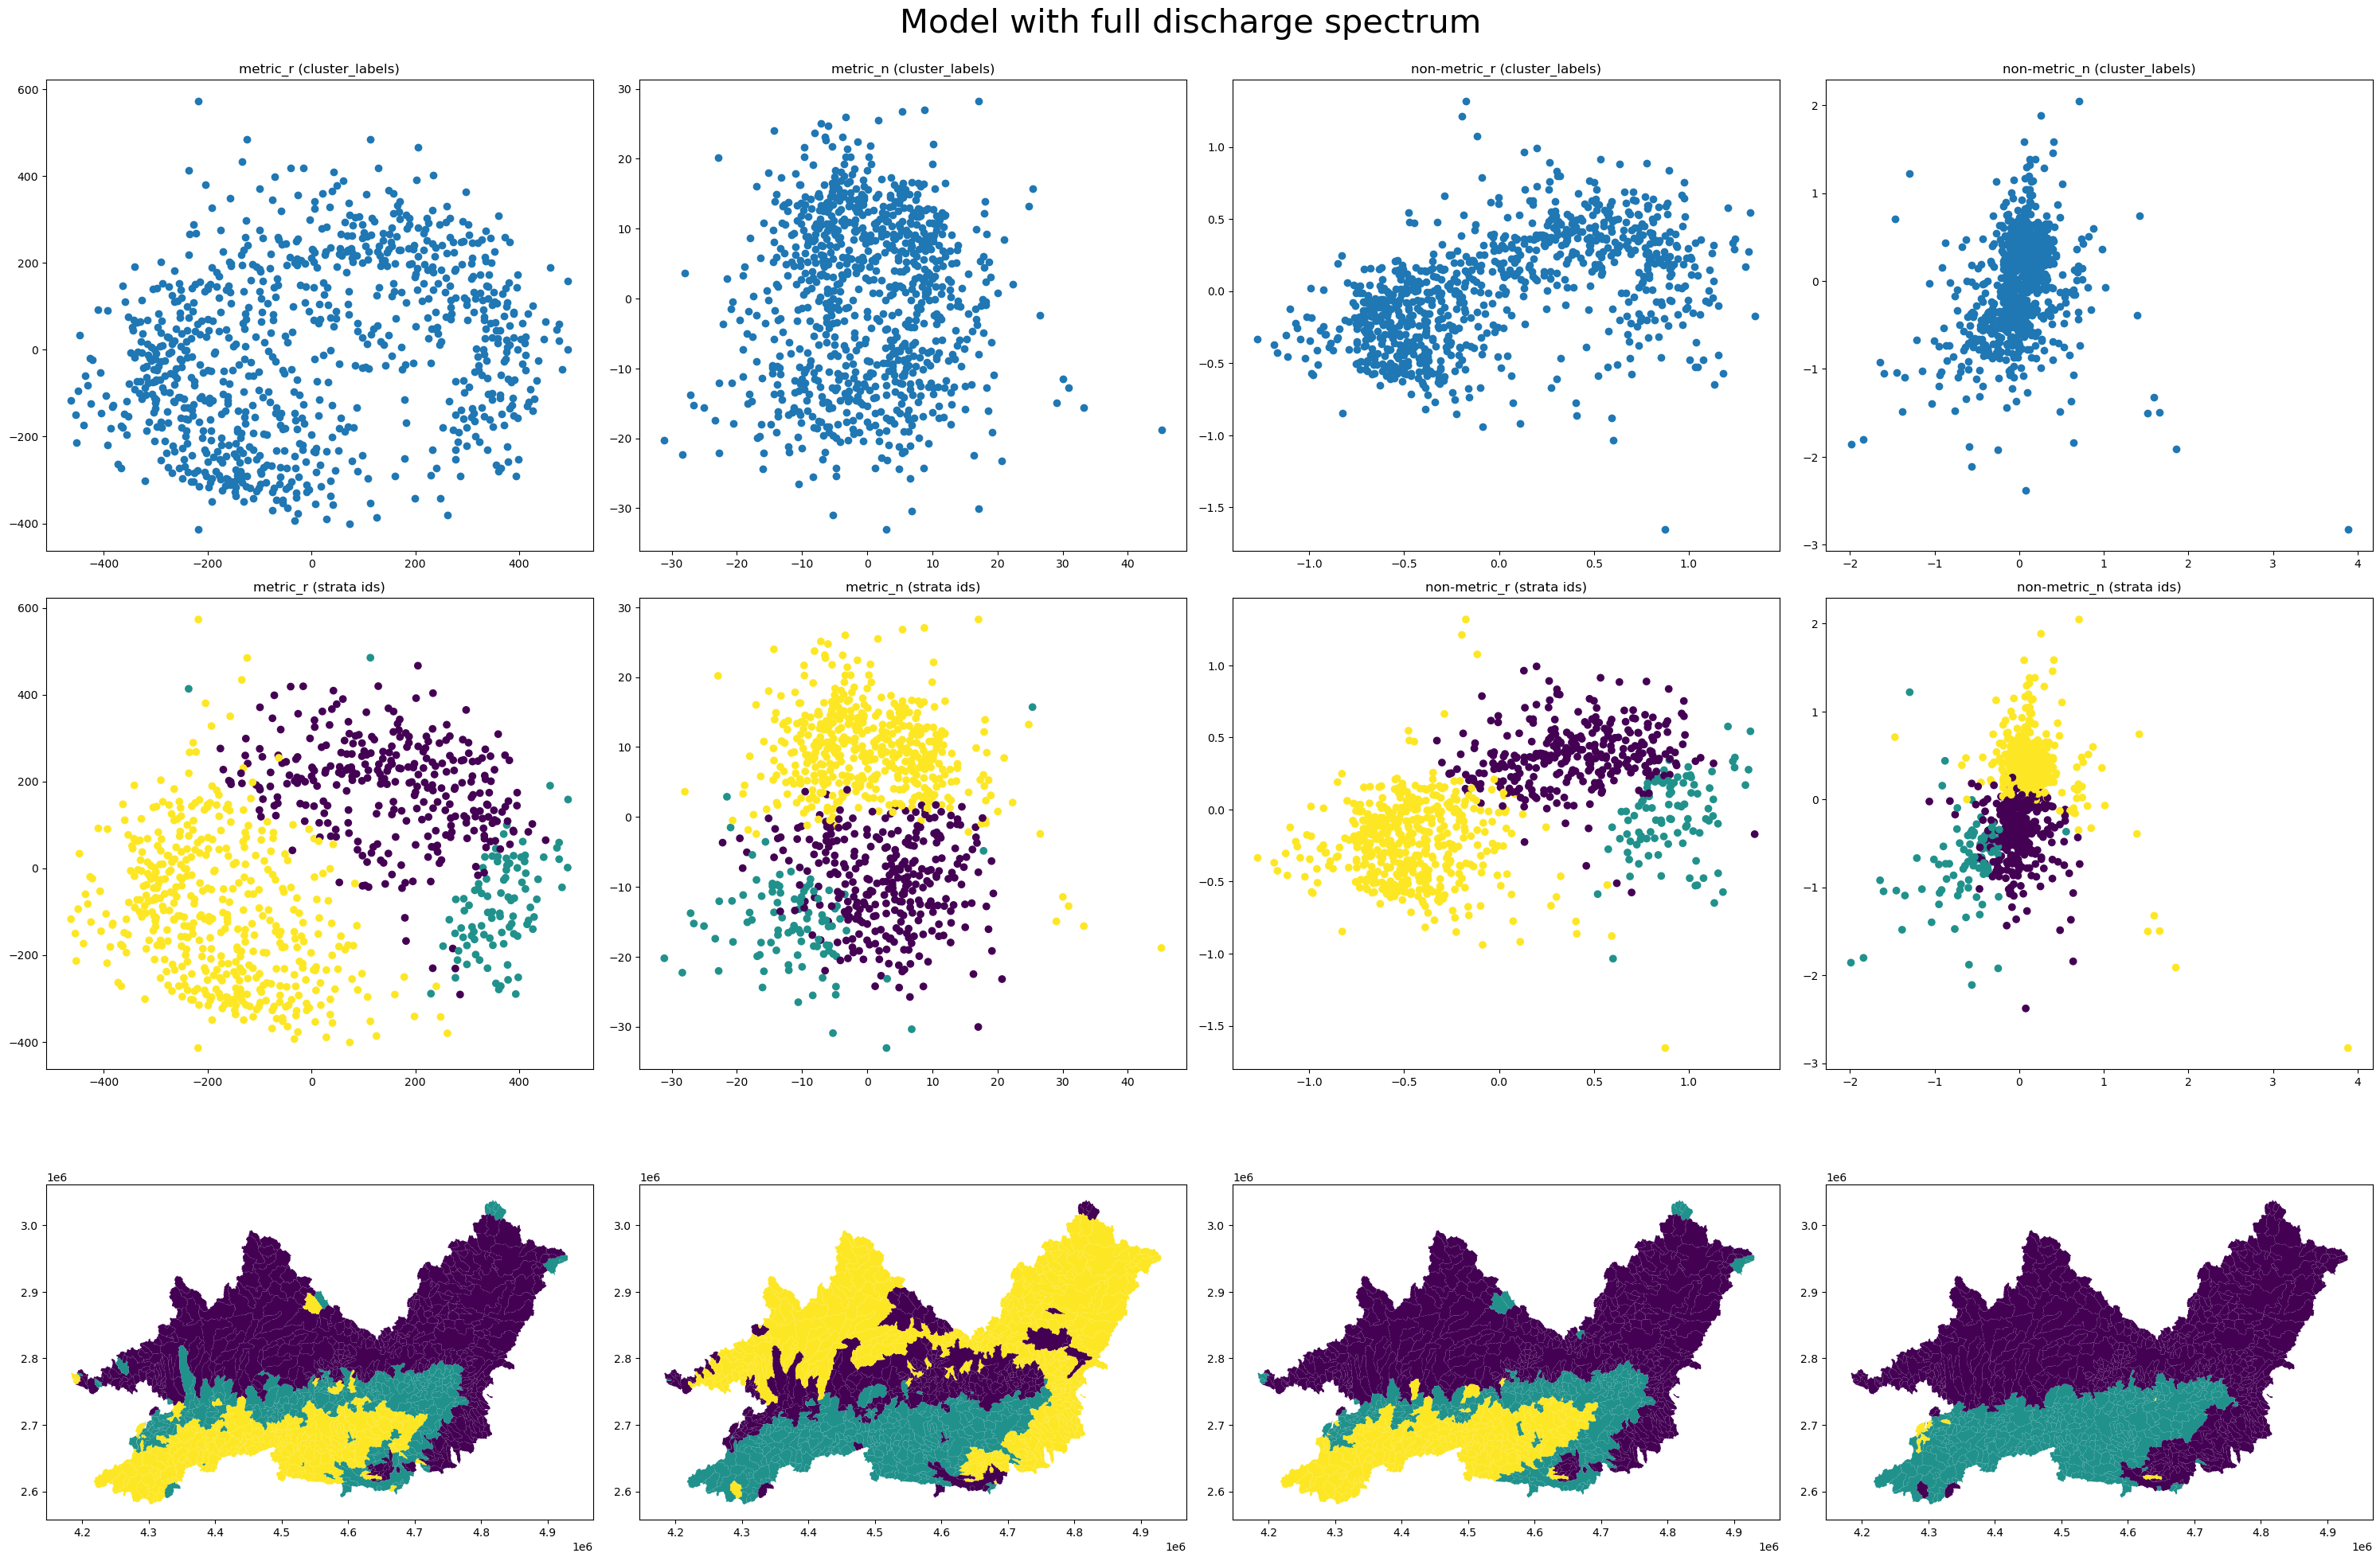

In [32]:
k_means = KMeans(3, random_state=774, max_iter=100)

fig, axs = plt.subplots(3,4, figsize=(30,20))
axs = axs.ravel()
fig.suptitle("Model with full discharge spectrum", fontsize=30, y=1)

for i, array, title in zip(
	[0,1,2,3],
	[means_mds["metric"][m] for m in ["raw", "normal"]] + [means_mds["non-metric"][m] for m in ["raw", "normal"]],
	["metric_r", "metric_n", "non-metric_r", "non-metric_n"]
):
	
	cluster = k_means.fit_predict(array)

	print(f"{len(cluster[cluster==-1])} basins could not be assined | {np.unique(cluster, return_counts=True)}")

	lamah_gdf[f"cluster_full_{title}"] = cluster		
	plot_cell_state_2d(array[cluster!=-1], ax=axs[i], title=f"{title} (cluster_labels)") 
	plot_cell_state_2d(array, ax=axs[i+4], title=f"{title} (strata ids)", c=strata_ids["0"])
	
	lamah_gdf.plot(ax=axs[i+8], column=f"cluster_full_{title}")

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/full_q_average_state_mds.png", dpi=300)
plt.tight_layout()

#### Raw cell states

In [33]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states.p", "rb") as f: 
	raw_cell_states = pickle.load(f)

raw_cell_states = dict(sorted(raw_cell_states.items(), key=lambda item: int(item[0])))

In [34]:
r_cs_array = np.vstack([raw_cell_states[b]["c_mean"] for b in raw_cell_states.keys()])

In [35]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

100%|██████████| 100/100 [00:19<00:00,  5.20it/s]


Text(0.5, 1.0, 'CH_scores')

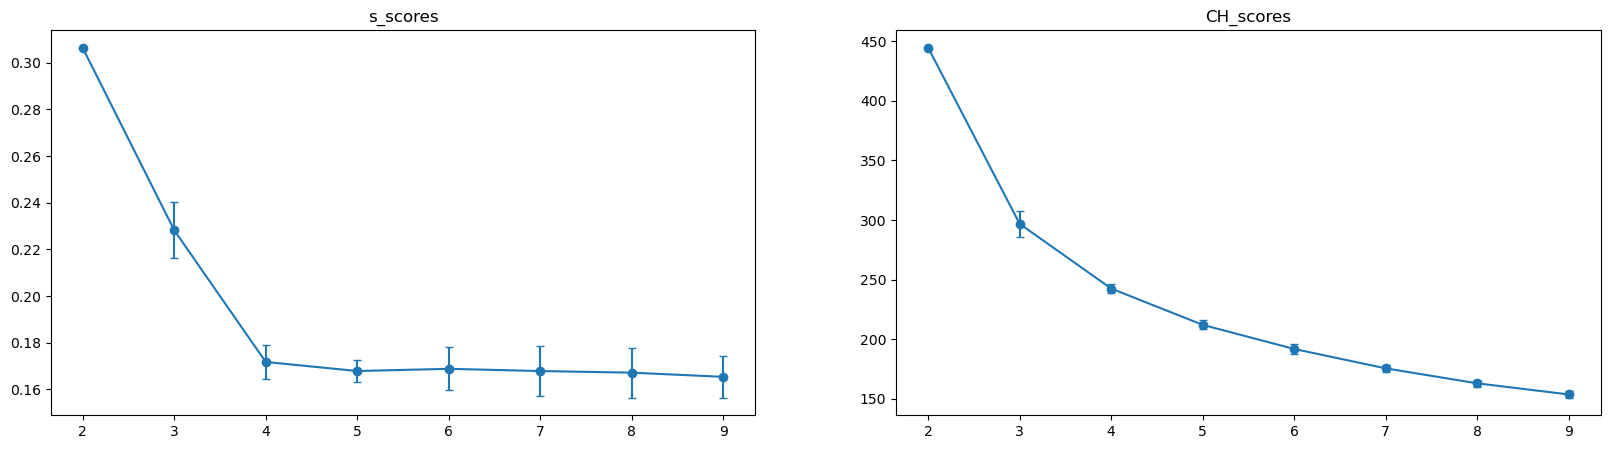

In [45]:
n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores = np.zeros([n_seeds,10]) 
CH_scores =  np.zeros([n_seeds,10])

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(r_cs_array)
		s_scores[i,k] = silhouette_score(r_cs_array,labels) # higher is better
		CH_scores[i,k] = calinski_harabasz_score(r_cs_array,labels) # higher is better
		
avg_s_scores = s_scores.mean(axis=0)[2:]
avg_ch_scores = CH_scores.mean(axis=0)[2:]

std_s_scores = s_scores.std(axis=0)[2:]
std_ch_scores = CH_scores.std(axis=0)[2:]

fig, axs = plt.subplots(1,2, figsize=(20,5))

axs[0].errorbar(range(2,10), avg_s_scores, yerr=std_s_scores, marker="o", capsize=3)
axs[1].errorbar(range(2,10), avg_ch_scores, yerr=std_ch_scores, marker="o", capsize=3)

axs[0].set_title("s_scores")
axs[1].set_title("CH_scores")

In [42]:
c = Counter(s_scores[:,3])
print(c)

Counter({0.23376567661762238: 5, 0.23616169393062592: 3, 0.2058887481689453: 1, 0.20563068985939026: 1})


In [46]:
print(Counter(CH_scores[:,3]))

Counter({302.3471780623902: 49, 302.25016356635246: 23, 276.7808207558222: 4, 276.83769966036647: 4, 276.75231661334107: 3, 302.34791317769697: 3, 302.35086431213: 3, 276.83829297156797: 2, 276.74183825883887: 2, 276.7150663097878: 2, 276.73442483723466: 1, 276.59462288901244: 1, 276.73881587780335: 1, 276.67491203384196: 1, 276.80972553649343: 1})


In [51]:
seeds[np.where(CH_scores[:,3] == Counter(CH_scores[:,3]).most_common(1)[0][0])[0][0]]

730

<Axes: >

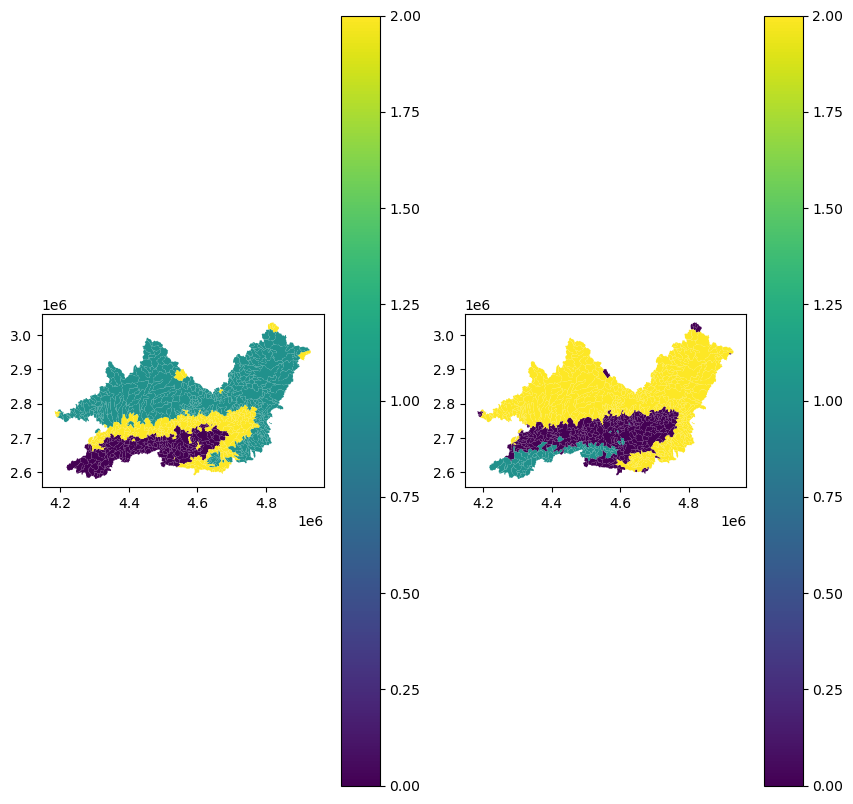

In [54]:
kmeans_seed = seeds[np.where(s_scores[:,3] == c.most_common(1)[0][0])[0][0]]

kmeans = KMeans(n_clusters=3, random_state=kmeans_seed, max_iter=100)

fig, axs = plt.subplots(1,2, figsize=(10,10))

cluster = kmeans.fit_predict(r_cs_array)

lamah_gdf["cluster"] = cluster

lamah_gdf.plot(column="cluster", ax=axs[0], legend=True)
lamah_gdf.plot(column="strata", ax=axs[1], legend=True)

In [59]:
from sklearn.metrics import jaccard_score

def ugly_label_mapper(x:int): 
	
	relabels ={
		"0": 1,
		"1": 2,
		"2": 0
	}

	return relabels[str(x)]
	

print(f"jaccard score {jaccard_score(lamah_gdf['strata'], lamah_gdf['cluster'].apply(ugly_label_mapper), average='weighted')}")


jaccard score 0.7704410139981576
